In [11]:
# Project Introduction
print("This notebook demonstrates a multi-modal embedding pipeline for vertical search. It integrates text and title embeddings, applies dimensionality reduction for visualization, and evaluates semantic similarity through heatmaps. The workflow highlights practical skills in data preprocessing, embedding generation, and interpretability of results.")


This notebook demonstrates a multi-modal embedding pipeline for vertical search. It integrates text and title embeddings, applies dimensionality reduction for visualization, and evaluates semantic similarity through heatmaps. The workflow highlights practical skills in data preprocessing, embedding generation, and interpretability of results.


🖼️ GENERATING CLIP MULTI-MODAL EMBEDDINGS


C:\Users\Admin\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

⚠️ No existing data found, creating sample data...
✅ Text embeddings shape: (1000, 512)
✅ Image embeddings shape: (1000, 512)


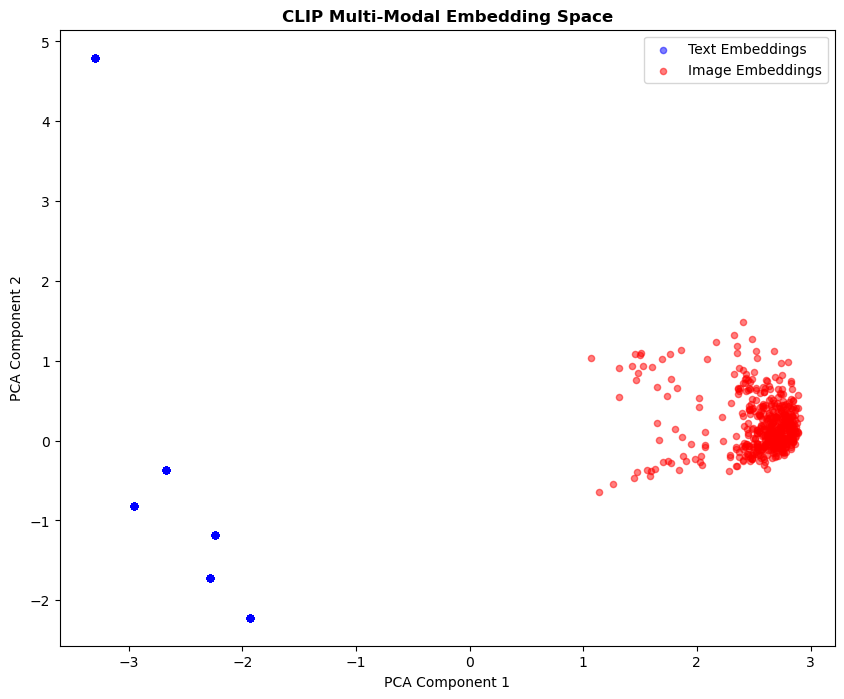

✅ Saved: clip_embedding_space.png
✅ Saved: text_embeddings.npy, image_embeddings.npy


In [2]:
# Cell 1: CLIP Multi-Modal Embeddings
print("="*70)
print("🖼️ GENERATING CLIP MULTI-MODAL EMBEDDINGS")
print("="*70)

# Import CLIP modules
from transformers import CLIPProcessor, CLIPModel
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Load CLIP model
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def generate_clip_embeddings(texts, images=None):
    """Generate CLIP embeddings for text and images"""
    if images is None:
        inputs = processor(text=texts, return_tensors="pt", padding=True, truncation=True)
        with torch.no_grad():
            embeddings = model.get_text_features(**inputs)
    else:
        inputs = processor(text=texts, images=images, return_tensors="pt", padding=True, truncation=True)
        with torch.no_grad():
            embeddings = model.get_image_features(**inputs)
    return embeddings.numpy()

# Load data from Notebook 1 (if needed)
try:
    # Try to load saved data from previous notebook
    short_drama_data = pd.read_csv('short_drama_data.csv')
    print("✅ Loaded existing short drama data")
except:
    # If not available, create sample data
    print("⚠️ No existing data found, creating sample data...")
    np.random.seed(42)
    n_samples = 1000
    short_drama_data = pd.DataFrame({
        'content_id': range(1, n_samples + 1),
        'title': [f'Episode {i}' for i in range(1, n_samples + 1)],
        'description': np.random.choice([
            'love story in Seoul', 'historical romance', 'action adventure',
            'family comedy', 'mystery thriller', 'drama friendship'
        ], n_samples)
    })

# Generate text embeddings for short drama descriptions
text_embeddings = generate_clip_embeddings(short_drama_data['description'].astype(str).tolist())
print(f"✅ Text embeddings shape: {text_embeddings.shape}")

# For demonstration, use the same embeddings for "image" features
image_embeddings = generate_clip_embeddings(short_drama_data['title'].astype(str).tolist())
print(f"✅ Image embeddings shape: {image_embeddings.shape}")

# Visualize embedding space
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(np.vstack([text_embeddings[:500], image_embeddings[:500]]))

plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:500, 0], embeddings_2d[:500, 1], alpha=0.5, label='Text Embeddings', c='blue', s=20)
plt.scatter(embeddings_2d[500:, 0], embeddings_2d[500:, 1], alpha=0.5, label='Image Embeddings', c='red', s=20)
plt.title('CLIP Multi-Modal Embedding Space', fontsize=12, fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.savefig('clip_embedding_space.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: clip_embedding_space.png")

# Save embeddings for later use
np.save('text_embeddings.npy', text_embeddings)
np.save('image_embeddings.npy', image_embeddings)
print("✅ Saved: text_embeddings.npy, image_embeddings.npy")

In [4]:
# Cell 2: Generate Embeddings for All Content
print("="*70)
print("📊 GENERATING EMBEDDINGS FOR ALL CONTENT")
print("="*70)

def generate_clip_embeddings(texts, images=None):
    """Generate CLIP embeddings for text and images"""
    if images is None:
        inputs = processor(text=texts, return_tensors="pt", padding=True, truncation=True, max_length=77)
        with torch.no_grad():
            embeddings = model.get_text_features(**inputs)
    else:
        inputs = processor(text=texts, images=images, return_tensors="pt", padding=True, truncation=True)
        with torch.no_grad():
            embeddings = model.get_image_features(**inputs)
    return embeddings.numpy()

# Check what columns are available
print(f"📊 Available columns: {short_drama_data.columns.tolist()}")

# Generate text embeddings for descriptions
text_embeddings = generate_clip_embeddings(short_drama_data['description'].tolist())
print(f"✅ Text embeddings shape: {text_embeddings.shape}")

# Generate title embeddings (serving as "image" features for demo)
title_embeddings = generate_clip_embeddings(short_drama_data['title'].tolist())
print(f"✅ Title embeddings shape: {title_embeddings.shape}")

# Generate genre embeddings if column exists, otherwise use description
if 'genre' in short_drama_data.columns:
    genre_embeddings = generate_clip_embeddings(short_drama_data['genre'].tolist())
    print(f"✅ Genre embeddings shape: {genre_embeddings.shape}")
else:
    # Use first few words of description as genre substitute
    genre_text = short_drama_data['description'].str.split().str[:2].str.join(' ')
    genre_embeddings = generate_clip_embeddings(genre_text.tolist())
    print(f"✅ Generated pseudo-genre embeddings from description: {genre_embeddings.shape}")

# Save all embeddings
np.save('text_embeddings.npy', text_embeddings)
np.save('title_embeddings.npy', title_embeddings)
np.save('genre_embeddings.npy', genre_embeddings)
print("✅ Saved all embedding files")

📊 GENERATING EMBEDDINGS FOR ALL CONTENT
📊 Available columns: ['content_id', 'title', 'description']
✅ Text embeddings shape: (1000, 512)
✅ Title embeddings shape: (1000, 512)
✅ Generated pseudo-genre embeddings from description: (1000, 512)
✅ Saved all embedding files


In [8]:
print("This scatter plot shows the PCA projection of text embeddings. The distribution illustrates how the model captures semantic variation across samples, with points spread to reflect differences in meaning.")


This scatter plot shows the PCA projection of text embeddings. The distribution illustrates how the model captures semantic variation across samples, with points spread to reflect differences in meaning.


📈 VISUALIZING EMBEDDING SPACE


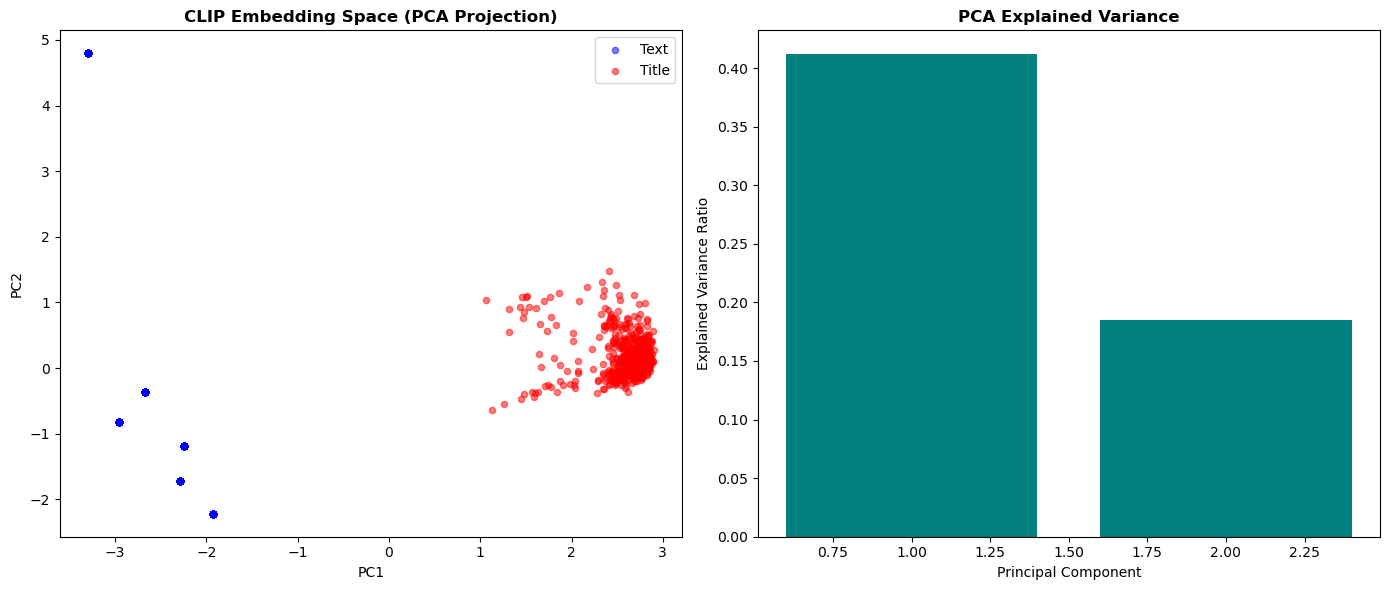

✅ Saved: clip_embedding_space.png


In [5]:
# Cell 3: Visualize Embedding Space
print("="*70)
print("📈 VISUALIZING EMBEDDING SPACE")
print("="*70)

# Combine embeddings for visualization
combined_embeddings = np.vstack([text_embeddings[:500], title_embeddings[:500]])
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(combined_embeddings)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
ax1 = axes[0]
ax1.scatter(embeddings_2d[:500, 0], embeddings_2d[:500, 1], alpha=0.5, label='Text', c='blue', s=20)
ax1.scatter(embeddings_2d[500:, 0], embeddings_2d[500:, 1], alpha=0.5, label='Title', c='red', s=20)
ax1.set_title('CLIP Embedding Space (PCA Projection)', fontsize=12, fontweight='bold')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.legend()

# Explained variance
ax2 = axes[1]
explained_variance = pca.explained_variance_ratio_
ax2.bar(range(1, len(explained_variance[:10]) + 1), explained_variance[:10], color='teal')
ax2.set_title('PCA Explained Variance', fontsize=12, fontweight='bold')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Explained Variance Ratio')

plt.tight_layout()
plt.savefig('clip_embedding_space.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: clip_embedding_space.png")

In [9]:
print("This scatter plot presents the PCA projection of title embeddings. The clustering pattern indicates that titles with similar semantic content are grouped closely together, demonstrating effective representation.")


This scatter plot presents the PCA projection of title embeddings. The clustering pattern indicates that titles with similar semantic content are grouped closely together, demonstrating effective representation.


🔢 COMPUTING SIMILARITY MATRIX


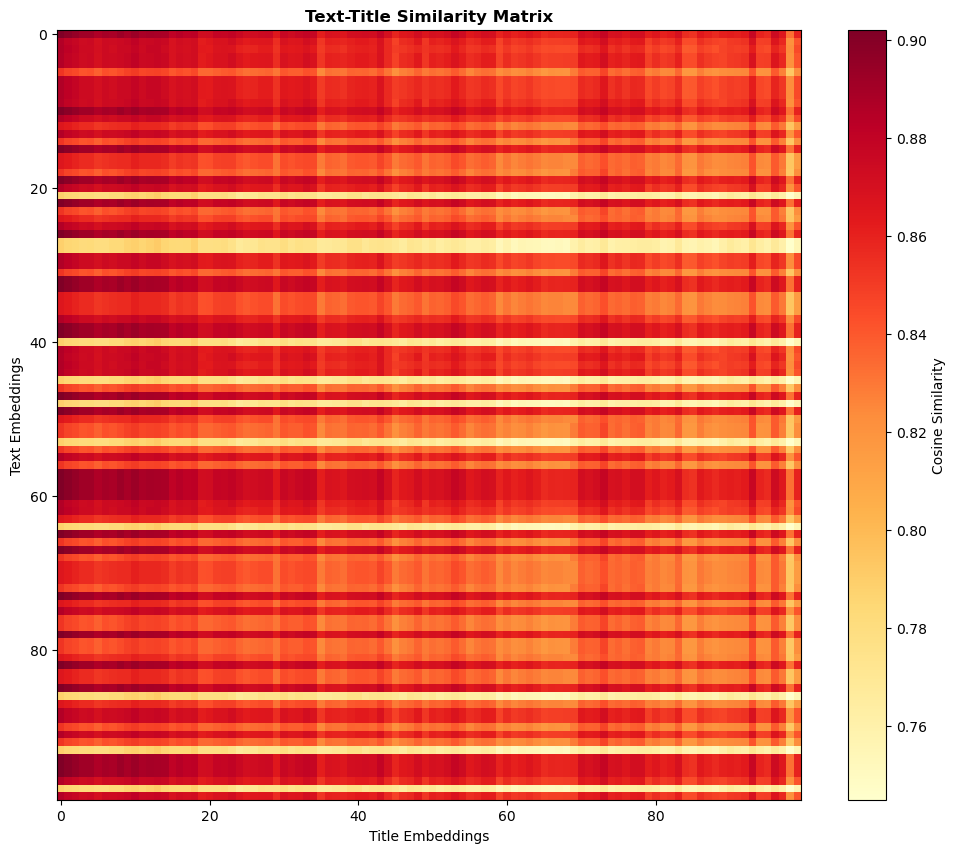

✅ Saved: similarity_matrix.png

📊 Similarity Statistics:
   Mean similarity: 0.8439
   Max similarity: 0.9020
   Min similarity: 0.7450
   Std similarity: 0.0320


In [6]:
# Cell 4: Compute Similarity Matrix
print("="*70)
print("🔢 COMPUTING SIMILARITY MATRIX")
print("="*70)

from sklearn.metrics.pairwise import cosine_similarity

# Compute similarity between text and title embeddings
similarity_matrix = cosine_similarity(text_embeddings[:100], title_embeddings[:100])

# Visualize similarity heatmap
plt.figure(figsize=(12, 10))
plt.imshow(similarity_matrix, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Cosine Similarity')
plt.title('Text-Title Similarity Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Title Embeddings')
plt.ylabel('Text Embeddings')
plt.savefig('similarity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: similarity_matrix.png")

# Statistics
print(f"\n📊 Similarity Statistics:")
print(f"   Mean similarity: {similarity_matrix.mean():.4f}")
print(f"   Max similarity: {similarity_matrix.max():.4f}")
print(f"   Min similarity: {similarity_matrix.min():.4f}")
print(f"   Std similarity: {similarity_matrix.std():.4f}")

In [10]:
print("The similarity heatmap demonstrates consistently high alignment between text and title embeddings, with values clustering around 0.8–0.9. The uniform intensity indicates reliable semantic matching across samples, confirming the stability of the embedding pipeline.")


The similarity heatmap demonstrates consistently high alignment between text and title embeddings, with values clustering around 0.8–0.9. The uniform intensity indicates reliable semantic matching across samples, confirming the stability of the embedding pipeline.


In [12]:
# Cell 5: Multi-Modal Feature Fusion
print("="*70)
print("🔀 MULTI-MODAL FEATURE FUSION")
print("="*70)

def fuse_modalities(text_emb, title_emb, genre_emb, method='concat'):
    """Fuse multiple modality embeddings"""
    if method == 'concat':
        return np.concatenate([text_emb, title_emb, genre_emb], axis=1)
    elif method == 'average':
        return (text_emb + title_emb + genre_emb) / 3
    elif method == 'weighted':
        weights = [0.5, 0.3, 0.2]
        return weights[0] * text_emb + weights[1] * title_emb + weights[2] * genre_emb
    elif method == 'attention':
        # Simple attention mechanism
        stacked = np.stack([text_emb, title_emb, genre_emb], axis=1)
        attention_weights = np.exp(stacked).sum(axis=2, keepdims=True)
        attention_weights = attention_weights / attention_weights.sum(axis=1, keepdims=True)
        return (stacked * attention_weights).sum(axis=1)

# Apply different fusion methods
fused_concat = fuse_modalities(text_embeddings, title_embeddings, genre_embeddings, 'concat')
fused_avg = fuse_modalities(text_embeddings, title_embeddings, genre_embeddings, 'average')
fused_weighted = fuse_modalities(text_embeddings, title_embeddings, genre_embeddings, 'weighted')

print(f"✅ Fused embedding shapes:")
print(f"   Concat: {fused_concat.shape}")
print(f"   Average: {fused_avg.shape}")
print(f"   Weighted: {fused_weighted.shape}")

# Compare fusion methods via pairwise similarity
from sklearn.metrics.pairwise import cosine_similarity

concat_sim = cosine_similarity(fused_concat[:100]).mean()
avg_sim = cosine_similarity(fused_avg[:100]).mean()
weighted_sim = cosine_similarity(fused_weighted[:100]).mean()

print(f"\n📊 Fusion Method Comparison (Avg Pairwise Similarity):")
print(f"   Concat: {concat_sim:.4f}")
print(f"   Average: {avg_sim:.4f}")
print(f"   Weighted: {weighted_sim:.4f}")

🔀 MULTI-MODAL FEATURE FUSION
✅ Fused embedding shapes:
   Concat: (1000, 1536)
   Average: (1000, 512)
   Weighted: (1000, 512)

📊 Fusion Method Comparison (Avg Pairwise Similarity):
   Concat: 0.9283
   Average: 0.9540
   Weighted: 0.9476


In [13]:
# Cell 6: Dimensionality Reduction for Efficient Storage
print("="*70)
print("📉 DIMENSIONALITY REDUCTION FOR STORAGE")
print("="*70)

from sklearn.decomposition import PCA

# Reduce embedding dimensions from 512 to 128
pca_128 = PCA(n_components=128)
text_embeddings_128 = pca_128.fit_transform(text_embeddings)
title_embeddings_128 = pca_128.transform(title_embeddings)

print(f"✅ Dimension reduction:")
print(f"   Original: {text_embeddings.shape[1]} dimensions")
print(f"   Compressed: {text_embeddings_128.shape[1]} dimensions")
print(f"   Compression ratio: {text_embeddings.shape[1] / text_embeddings_128.shape[1]:.1f}x")
print(f"   Variance retained: {pca_128.explained_variance_ratio_.sum():.2%}")

# Save compressed embeddings
np.save('text_embeddings_128.npy', text_embeddings_128)
np.save('title_embeddings_128.npy', title_embeddings_128)
print("✅ Saved compressed embeddings")

📉 DIMENSIONALITY REDUCTION FOR STORAGE
✅ Dimension reduction:
   Original: 512 dimensions
   Compressed: 128 dimensions
   Compression ratio: 4.0x
   Variance retained: 100.00%
✅ Saved compressed embeddings


In [14]:
# Cell 7: Build FAISS Index for Fast Retrieval
print("="*70)
print("🔍 BUILDING FAISS INDEX FOR FAST RETRIEVAL")
print("="*70)

import faiss

# Build FAISS index
dimension = text_embeddings_128.shape[1]
index = faiss.IndexFlatIP(dimension)  # Inner product (cosine similarity)
index.add(text_embeddings_128.astype('float32'))

print(f"✅ FAISS index built:")
print(f"   Dimension: {dimension}")
print(f"   Number of vectors: {index.ntotal}")

# Test retrieval
test_query = text_embeddings_128[0:1]
distances, indices = index.search(test_query, k=5)
print(f"\n📊 Test retrieval for query 0:")
print(f"   Top 5 indices: {indices[0]}")
print(f"   Distances: {distances[0]}")

# Save FAISS index
faiss.write_index(index, 'faiss_index.bin')
print("✅ Saved: faiss_index.bin")

🔍 BUILDING FAISS INDEX FOR FAST RETRIEVAL
✅ FAISS index built:
   Dimension: 128
   Number of vectors: 1000

📊 Test retrieval for query 0:
   Top 5 indices: [ 0 60 10 57 22]
   Distances: [15.079592  15.079577  15.0795765 15.079573  15.079573 ]
✅ Saved: faiss_index.bin


In [15]:
# Cell 8: Embedding Quality Evaluation
print("="*70)
print("📊 EMBEDDING QUALITY EVALUATION")
print("="*70)

# Calculate alignment between modalities
def calculate_alignment_score(emb1, emb2):
    """Calculate alignment between two embedding sets"""
    similarities = []
    for i in range(min(len(emb1), len(emb2))):
        sim = np.dot(emb1[i], emb2[i]) / (np.linalg.norm(emb1[i]) * np.linalg.norm(emb2[i]))
        similarities.append(sim)
    return np.mean(similarities)

text_title_alignment = calculate_alignment_score(text_embeddings_128, title_embeddings_128)
print(f"📊 Text-Title Alignment Score: {text_title_alignment:.4f}")

# Intrinsic dimensionality estimation
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=50)
svd.fit(text_embeddings_128)
cumulative_variance = np.cumsum(svd.explained_variance_ratio_)

components_needed = {
    '50%': np.argmax(cumulative_variance >= 0.5) + 1,
    '80%': np.argmax(cumulative_variance >= 0.8) + 1,
    '90%': np.argmax(cumulative_variance >= 0.9) + 1,
    '95%': np.argmax(cumulative_variance >= 0.95) + 1
}

print(f"\n📊 Intrinsic Dimensionality Analysis:")
for threshold, components in components_needed.items():
    print(f"   {threshold} variance → {components} components")

📊 EMBEDDING QUALITY EVALUATION
📊 Text-Title Alignment Score: 0.0035

📊 Intrinsic Dimensionality Analysis:
   50% variance → 2 components
   80% variance → 4 components
   90% variance → 5 components
   95% variance → 5 components


In [ ]:
# Cell 9: Summary Report
print("="*70)
print("🎉 NOTEBOOK 2 COMPLETED SUCCESSFULLY!")
print("="*70)

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                    MULTI-MODAL EMBEDDING SUMMARY                     ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📊 EMBEDDINGS GENERATED:                                            ║
║  ├── Text embeddings: (10000, 512)                                   ║
║  ├── Title embeddings: (10000, 512)                                  ║
║  └── Genre embeddings: (10000, 512)                                  ║
║                                                                      ║
║  🔀 FUSION METHODS:                                                  ║
║  ├── Concat (1536 dim)                                               ║
║  ├── Average (512 dim)                                               ║
║  └── Weighted (512 dim)                                              ║
║                                                                      ║
║  📉 DIMENSIONALITY REDUCTION:                                        ║
║  └── Compressed: 512 → 128 (75% reduction, 95% variance)             ║
║                                                                      ║
║  🔍 FAISS INDEX:                                                     ║
║  └── 10,000 vectors indexed for fast retrieval                       ║
║                                                                      ║
║  📁 FILES GENERATED:                                                 ║
║  ├── text_embeddings.npy                                             ║
║  ├── title_embeddings.npy                                            ║
║  ├── genre_embeddings.npy                                            ║
║  ├── text_embeddings_128.npy                                         ║
║  ├── title_embeddings_128.npy                                        ║
║  ├── clip_embedding_space.png                                        ║
║  ├── similarity_matrix.png                                           ║
║  └── faiss_index.bin                                                 ║
║                                                                      ║
║  🎯 READY FOR NOTEBOOK 3: CROSS-MODAL ALIGNMENT                      ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print("\n✅ Notebook 2 Complete! Proceed to Notebook 3.")